# Quick View Processed Data

Notebook pequeno para inspeccionar salidas procesadas (`.pt` o `.npz`).

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

try:
    import torch
except Exception:
    torch = None

print('torch disponible:', torch is not None)

torch disponible: True


In [ ]:
# Config base del notebook: visualizacion por capas usando data/processed/norm
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'data').exists() and (REPO_ROOT.parent / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

PROCESSED_DIR = REPO_ROOT / 'data' / 'processed' / 'train' / '001_LatinHypercube'
# PROCESSED_DIR = REPO_ROOT / 'data' / 'processed' / 'test' / '019_normal'

REPORTS = {
    'sf_vd': 'layer_cubes_report.json',
    'permeability': 'permeability_layer_cubes_report.json',
    'porosity': 'porosity_layer_cubes_report.json',
    'cohesion': 'cohesion_layer_cubes_report.json',
    'afi': 'afi_layer_cubes_report.json',
    'pressure': 'pressure_layer_cubes_report.json',
    'gas_saturation': 'gas_saturation_layer_cubes_report.json',
    'injection': 'injection_name_tensors_report.json',
}

print('REPO_ROOT:', REPO_ROOT)
print('PROCESSED_DIR:', PROCESSED_DIR)

for name, filename in REPORTS.items():
    path = PROCESSED_DIR / filename
    print(f'{name:<15} ->', '| existe:', path.exists())





REPO_ROOT: L:\cmg22tensor
PROCESSED_DIR: L:\cmg22tensor\data\processed\001_LatinHypercube
sf_vd           -> | existe: True
permeability    -> | existe: True
porosity        -> | existe: True
cohesion        -> | existe: True
afi             -> | existe: True
pressure        -> | existe: False
gas_saturation  -> | existe: False
injection       -> | existe: True


In [3]:
from math import ceil

def resolve_path_from_report(path_value) -> Path:
    raw = str(path_value).replace('\\', '/').strip()
    p = Path(raw)

    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        if p.parts and p.parts[0].lower() == 'data':
            candidates.append(REPO_ROOT / p)
        candidates.append((PROCESSED_DIR / p).resolve())
        candidates.append((PROCESSED_DIR / p.name).resolve())

    unique_candidates = []
    seen = set()
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(c)

    for c in unique_candidates:
        if c.exists():
            return c

    return unique_candidates[0] if unique_candidates else p


def load_report(report_name: str) -> dict:
    if report_name not in REPORTS:
        raise KeyError(f'Dataset no soportado: {report_name}. Opciones: {list(REPORTS.keys())}')
    path = PROCESSED_DIR / REPORTS[report_name]
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_layer_cube(file_path: Path) -> dict:
    if file_path.suffix == '.pt':
        if torch is None:
            raise RuntimeError('No hay torch en el entorno para leer .pt')
        payload = torch.load(file_path, map_location='cpu')
        cube = payload['cube']
        if hasattr(cube, 'detach'):
            cube = cube.detach().cpu().numpy()
        return {
            'cube': np.asarray(cube),
            'time_ids': list(payload.get('time_ids', [])),
            'time_ids_days': list(payload.get('time_ids_days', [])),
            'time_unit': str(payload.get('time_unit', 'days')),
            'variables': list(payload.get('variables', [])),
            'layer_k': int(payload.get('layer_k', -1)),
            'normalization': payload.get('normalization', None),
        }

    if file_path.suffix == '.npz':
        with np.load(file_path, allow_pickle=True) as payload:
            variables = payload['variables']
            if hasattr(variables, 'tolist'):
                variables = variables.tolist()

            time_ids_days = payload['time_ids_days'].tolist() if 'time_ids_days' in payload else []
            time_unit = str(payload['time_unit'].tolist()[0]) if 'time_unit' in payload else 'days'

            normalization = None
            if 'normalization_method' in payload or 'normalization_applied' in payload:
                method = str(payload['normalization_method'].tolist()[0]) if 'normalization_method' in payload else 'none'
                applied = bool(int(payload['normalization_applied'].tolist()[0])) if 'normalization_applied' in payload else False
                normalization = {'method': method, 'applied': applied}

            return {
                'cube': np.asarray(payload['cube']),
                'time_ids': np.asarray(payload['time_ids']).tolist(),
                'time_ids_days': time_ids_days,
                'time_unit': time_unit,
                'variables': [str(v) for v in variables],
                'layer_k': int(np.asarray(payload['layer_k']).reshape(-1)[0]),
                'normalization': normalization,
            }

    raise ValueError(f'Formato no soportado: {file_path}')


def describe_cube(cube: np.ndarray) -> dict:
    return {
        'shape': tuple(cube.shape),
        'nan_count': int(np.isnan(cube).sum()),
        'min': float(np.nanmin(cube)),
        'max': float(np.nanmax(cube)),
        'mean': float(np.nanmean(cube)),
    }


def _list_layer_files(dataset: str) -> tuple[list[Path], Path]:
    report = load_report(dataset)
    output_dir = resolve_path_from_report(report['output_dir'])
    files = sorted(output_dir.glob('layer_cube_k*.pt')) + sorted(output_dir.glob('layer_cube_k*.npz'))
    if not files:
        raise RuntimeError(
            f'No hay archivos layer_cube_k*.pt/.npz para {dataset} en {output_dir}. '
            'Usa una corrida por capas (data/processed/norm).'
        )
    return files, output_dir


def _load_full_tensor_from_path(path: Path) -> dict:
    if path.suffix == '.pt':
        if torch is None:
            raise RuntimeError('No hay torch en el entorno para leer .pt')
        payload = torch.load(path, map_location='cpu')
        tensor = payload.get('tensor')
        if hasattr(tensor, 'detach'):
            tensor = tensor.detach().cpu().numpy()
        return {
            'tensor': np.asarray(tensor),
            'variables': list(payload.get('variables', [])),
            'time_ids': list(payload.get('time_ids', [])),
            'time_ids_days': list(payload.get('time_ids_days', [])),
            'axes': list(payload.get('axes', ['V', 'T', 'Z', 'J', 'I'])),
            'source': str(path),
            'normalization': payload.get('normalization', None),
        }

    if path.suffix == '.npz':
        with np.load(path, allow_pickle=True) as payload:
            variables = payload['variables'].tolist() if 'variables' in payload else []
            axes = payload['axes'].tolist() if 'axes' in payload else ['V', 'T', 'Z', 'J', 'I']
            return {
                'tensor': np.asarray(payload['tensor']),
                'variables': [str(v) for v in variables],
                'time_ids': payload['time_ids'].tolist() if 'time_ids' in payload else [],
                'time_ids_days': payload['time_ids_days'].tolist() if 'time_ids_days' in payload else [],
                'axes': [str(a) for a in axes],
                'source': str(path),
                'normalization': None,
            }

    raise ValueError(f'Formato no soportado para full tensor: {path}')


def construir_tensor_5d(dataset: str, source_mode: str = 'auto') -> dict:
    source_mode = source_mode.lower().strip()
    if source_mode not in {'auto', 'layer', 'full'}:
        raise ValueError("source_mode debe ser 'auto', 'layer' o 'full'")

    report = load_report(dataset)
    full_info = None
    full_path = report.get('full_tensor_path')
    if full_path:
        fp = resolve_path_from_report(full_path)
        if fp.exists():
            full_info = _load_full_tensor_from_path(fp)

    if source_mode == 'full':
        if full_info is None:
            raise RuntimeError(f'No hay full tensor disponible para {dataset}')
        info = full_info
    elif source_mode == 'layer':
        files, output_dir = _list_layer_files(dataset)
        layers = []
        sample_meta = None
        for fp in files:
            obj = load_layer_cube(fp)
            layers.append(np.asarray(obj['cube']))
            if sample_meta is None:
                sample_meta = obj
        info = {
            'tensor': np.stack(layers, axis=2),
            'variables': sample_meta.get('variables', []),
            'time_ids': sample_meta.get('time_ids', []),
            'time_ids_days': sample_meta.get('time_ids_days', []),
            'axes': ['V', 'T', 'Z', 'J', 'I'],
            'source': f'layer_cubes::{output_dir}',
            'normalization': sample_meta.get('normalization', None),
        }
    else:
        if full_info is not None:
            info = full_info
        else:
            info = construir_tensor_5d(dataset, source_mode='layer')

    tensor = np.asarray(info['tensor'])
    if tensor.ndim != 5:
        raise RuntimeError(f'Se esperaba tensor 5D (V,T,Z,J,I), recibido shape={tensor.shape}')
    return info


def resumen_dataset(dataset: str, source_mode: str = 'auto') -> None:
    info = construir_tensor_5d(dataset, source_mode=source_mode)
    tensor = np.asarray(info['tensor'])
    variables = info.get('variables', [])
    time_ids = info.get('time_ids', [])
    print('dataset:', dataset)
    print('source:', info.get('source', 'unknown'))
    print('shape (V,T,Z,J,I):', tensor.shape)
    print('variables:', variables if variables else 'N/A')
    print('time_ids sample:', time_ids[:10] if time_ids else 'N/A')
    print('normalization:', info.get('normalization', None))
    print('stats global:', describe_cube(tensor))


def graficar_capa(
    dataset: str,
    capa: int = 0,
    variable: int = 0,
    tiempo: int = 0,
    cmap: str = 'viridis',
    source_mode: str = 'auto',
    figsize: tuple[float, float] = (5, 5),
) -> None:
    info = construir_tensor_5d(dataset, source_mode=source_mode)
    tensor = np.asarray(info['tensor'])
    V, T, Z, _, _ = tensor.shape

    if not (0 <= variable < V):
        raise ValueError(f'variable fuera de rango: {variable}, V={V}')
    if not (0 <= tiempo < T):
        raise ValueError(f'tiempo fuera de rango: {tiempo}, T={T}')
    if not (0 <= capa < Z):
        raise ValueError(f'capa fuera de rango: {capa}, Z={Z}')

    slice_2d = tensor[variable, tiempo, capa]
    variables = info.get('variables', [])
    time_ids = info.get('time_ids', [])
    time_ids_days = info.get('time_ids_days', [])

    var_name = variables[variable] if variable < len(variables) else f'var_{variable}'
    month_value = time_ids[tiempo] if tiempo < len(time_ids) else tiempo
    day_value = time_ids_days[tiempo] if tiempo < len(time_ids_days) else 'N/A'

    plt.figure(figsize=figsize)
    im = plt.imshow(slice_2d, cmap=cmap, origin='lower', aspect='auto')
    #plt.colorbar(im, label='value')
    #plt.title(f'{dataset} | layer={capa} | var={var_name} | month={month_value} | day={day_value}')
    plt.xlabel('I')
    plt.ylabel('J')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def graficar_cubo(
    dataset: str,
    variable: int = 0,
    tiempo: int = 0,
    capas: list[int] | None = None,
    max_capas: int | None = None,
    cols: int = 4,
    cmap: str = 'viridis',
    source_mode: str = 'auto',
    figsize_por_subplot: tuple[float, float] = (3.4, 3.0),
) -> None:
    info = construir_tensor_5d(dataset, source_mode=source_mode)
    tensor = np.asarray(info['tensor'])
    V, T, Z, _, _ = tensor.shape

    if not (0 <= variable < V):
        raise ValueError(f'variable fuera de rango: {variable}, V={V}')
    if not (0 <= tiempo < T):
        raise ValueError(f'tiempo fuera de rango: {tiempo}, T={T}')
    
    variables = info.get('variables', [])
    var_name = variables[variable] if variable < len(variables) else f'var_{variable}'

    if capas is None:
        capas = list(range(Z))
    else:
        capas = [int(c) for c in capas]

    if max_capas is not None:
        capas = capas[:max_capas]

    if not capas:
        raise ValueError('No hay capas para graficar.')

    for c in capas:
        if not (0 <= c < Z):
            raise ValueError(f'capa fuera de rango: {c}, Z={Z}')

    data = tensor[variable, tiempo, capas, :, :]
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)

    n = len(capas)
    cols = max(1, min(cols, n))
    rows = ceil(n / cols)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_por_subplot[0] * cols, figsize_por_subplot[1] * rows),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, capa in enumerate(capas):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        im = ax.imshow(tensor[variable, tiempo, capa], cmap=cmap, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
        ax.set_title(f'layer={capa}')
        ax.set_xlabel('I')
        ax.set_ylabel('J')

    for idx in range(n, rows * cols):
        r = idx // cols
        c = idx % cols
        axes[r][c].axis('off')

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='value')
    fig.suptitle(f'{dataset} | cube view | var={var_name} | time={tiempo}')
    plt.show()


def graficar_histograma(
    dataset: str,
    variable: int = 0,
    tiempo: int | None = None,
    capa: int | None = None,
    bins: int = 80,
    log_y: bool = False,
    source_mode: str = 'auto',
    figsize: tuple[float, float] = (8, 4),
) -> None:
    info = construir_tensor_5d(dataset, source_mode=source_mode)
    tensor = np.asarray(info['tensor'])
    V, T, Z, _, _ = tensor.shape

    if not (0 <= variable < V):
        raise ValueError(f'variable fuera de rango: {variable}, V={V}')

    subset = tensor[variable]

    if tiempo is not None:
        if not (0 <= tiempo < T):
            raise ValueError(f'tiempo fuera de rango: {tiempo}, T={T}')
        subset = subset[tiempo:tiempo + 1]

    if capa is not None:
        if not (0 <= capa < Z):
            raise ValueError(f'capa fuera de rango: {capa}, Z={Z}')
        subset = subset[:, capa:capa + 1]

    values = subset[np.isfinite(subset)].ravel()
    if values.size == 0:
        raise RuntimeError('No hay valores finitos para graficar histograma.')

    variables = info.get('variables', [])
    var_name = variables[variable] if variable < len(variables) else f'var_{variable}'

    plt.figure(figsize=figsize)
    plt.hist(values, bins=bins, alpha=0.85, edgecolor='black', linewidth=0.3)
    if log_y:
        plt.yscale('log')

    title = f'Histograma | {dataset} | {var_name}'
    if tiempo is not None:
        title += f' | T={tiempo}'
    if capa is not None:
        title += f' | Z={capa}'

    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def graficar_capa_tiempo(
    dataset: str,
    capa: int = 0,
    variable: int = 0,
    tiempos: list[int] | None = None,
    max_tiempos: int = 12,
    paso: int | None = None,
    source_mode: str = 'auto',
    cols: int = 4,
    cmap: str = 'viridis',
    figsize_por_subplot: tuple[float, float] = (3.5, 3.2),
    escala_global: bool = True,
) -> None:
    info = construir_tensor_5d(dataset, source_mode=source_mode)
    tensor = np.asarray(info['tensor'])
    V, T, Z, _, _ = tensor.shape

    if not (0 <= variable < V):
        raise ValueError(f'variable fuera de rango: {variable}, V={V}')
    if not (0 <= capa < Z):
        raise ValueError(f'capa fuera de rango: {capa}, Z={Z}')

    if tiempos is None:
        if paso is not None:
            if paso <= 0:
                raise ValueError(f'paso debe ser > 0. Recibido: {paso}')
            tiempos_sel = list(range(0, T, paso))
        else:
            n = min(max_tiempos, T)
            tiempos_sel = np.linspace(0, T - 1, num=n, dtype=int).tolist()
    else:
        tiempos_sel = sorted(set(int(t) for t in tiempos))

    if not tiempos_sel:
        raise ValueError('No hay tiempos para graficar.')

    for t in tiempos_sel:
        if not (0 <= t < T):
            raise ValueError(f'tiempo fuera de rango: {t}, T={T}')

    if max_tiempos is not None and len(tiempos_sel) > max_tiempos:
        tiempos_sel = tiempos_sel[:max_tiempos]

    variables = info.get('variables', [])
    var_name = variables[variable] if variable < len(variables) else f'var_{variable}'
    time_ids = info.get('time_ids', [])
    time_ids_days = info.get('time_ids_days', [])

    # Extraer solo lo que se va a graficar: (T, Y, X)
    data_plot = tensor[variable, :, capa]

    # Aplicar máscara solo para pressure
    if dataset == 'pressure':
        data_plot = np.ma.masked_where(data_plot == 0, data_plot)

    if escala_global:
        vmin = float(np.ma.min(data_plot))
        vmax = float(np.ma.max(data_plot))
    else:
        vmin = vmax = None

    n = len(tiempos_sel)
    cols = max(1, min(cols, n))
    rows = ceil(n / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_por_subplot[0] * cols, figsize_por_subplot[1] * rows),
        squeeze=False,
        constrained_layout=True,
    )

    im = None
    for idx, t in enumerate(tiempos_sel):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]

        im = ax.imshow(
            data_plot[t],
            cmap=cmap,
            origin='lower',
            aspect='auto',
            vmin=vmin,
            vmax=vmax,
        )

        month_label = time_ids[t] if t < len(time_ids) else t
        day_label = time_ids_days[t] if t < len(time_ids_days) else 'N/A'
        ax.set_title(f'Month={month_label} | day={day_label}')
        ax.set_xlabel('I')
        ax.set_ylabel('J')

    for idx in range(n, rows * cols):
        r = idx // cols
        c = idx % cols
        axes[r][c].axis('off')

    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='value')

    fig.suptitle(f'{dataset} | layer={capa} | var={var_name} | Evolucion Temporal')
    plt.show()

def graficar_capa_diff_tiempo(
    dataset: str,
    capa: int = 0,
    variable: int = 0,
    t1: int = 0,
    t2: int = 1,
    source_mode: str = 'auto',
    cmap: str = 'viridis',
    diff_cmap: str = 'RdBu_r',
    save_dir=None,
) -> None:
    """Compara una capa (Z) entre dos tiempos y grafica el diff (t1 - t2).

    Firma consistente con el resto de funciones del notebook:
    `dataset='sf_vd'`, `variable=0`, `capa=45`, `t1=60`, `t2=120`.

    - dataset: llave en REPORTS (ej: 'sf_vd')
    - capa: indice Z (0-based)
    - variable: indice V (0-based)
    - t1, t2: indices de tiempo T (0-based)

    Nota: en modo `auto` intenta leer solo el archivo de la capa (layer_cube_kXXX)
    para evitar cargar el tensor completo. Si pides `source_mode='full'`, usa el
    full tensor si esta disponible.
    """
    source_mode = source_mode.lower().strip()
    if source_mode not in {'auto', 'layer', 'full'}:
        raise ValueError("source_mode debe ser 'auto', 'layer' o 'full'")

    meta = {}

    if source_mode in {'auto', 'layer'}:
        try:
            files, _ = _list_layer_files(dataset)
            if not (0 <= capa < len(files)):
                raise ValueError(f'capa fuera de rango: {capa}, Z={len(files)}')
            obj = load_layer_cube(files[capa])
            layer_cube = np.asarray(obj['cube'])  # (V, T, J, I)
            meta = obj

            if layer_cube.ndim != 4:
                raise RuntimeError(f'Se esperaba cube 4D (V,T,J,I), recibido shape={layer_cube.shape}')

            V, T, _, _ = layer_cube.shape
            if not (0 <= variable < V):
                raise ValueError(f'variable fuera de rango: {variable}, V={V}')
            if not (0 <= t1 < T) or not (0 <= t2 < T):
                raise ValueError(f'tiempo fuera de rango: t1={t1}, t2={t2}, T={T}')

            m1 = layer_cube[variable, t1]
            m2 = layer_cube[variable, t2]
        except Exception:
            if source_mode == 'layer':
                raise
            source_mode = 'full'

    if source_mode == 'full':
        info = construir_tensor_5d(dataset, source_mode='full')
        tensor = np.asarray(info['tensor'])  # (V,T,Z,J,I)
        V, T, Z, _, _ = tensor.shape

        if not (0 <= variable < V):
            raise ValueError(f'variable fuera de rango: {variable}, V={V}')
        if not (0 <= capa < Z):
            raise ValueError(f'capa fuera de rango: {capa}, Z={Z}')
        if not (0 <= t1 < T) or not (0 <= t2 < T):
            raise ValueError(f'tiempo fuera de rango: t1={t1}, t2={t2}, T={T}')

        m1 = tensor[variable, t1, capa]
        m2 = tensor[variable, t2, capa]
        meta = {
            'variables': info.get('variables', []),
            'time_ids': info.get('time_ids', []),
            'time_ids_days': info.get('time_ids_days', []),
            'layer_k': None,
        }

    diff = m1 - m2

    stacked = np.r_[m1[np.isfinite(m1)].ravel(), m2[np.isfinite(m2)].ravel()]
    if stacked.size:
        vmin = float(np.nanpercentile(stacked, 1))
        vmax = float(np.nanpercentile(stacked, 99))
    else:
        vmin = vmax = None

    d = float(np.nanpercentile(np.abs(diff), 99)) if np.isfinite(diff).any() else 0.0
    if d == 0.0:
        d = 1e-12
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-d, vmax=d)

    variables = list(meta.get('variables', []))
    var_name = variables[variable] if variable < len(variables) else f'var_{variable}'

    time_ids = list(meta.get('time_ids', []))
    time_ids_days = list(meta.get('time_ids_days', []))
    id1 = time_ids[t1] if t1 < len(time_ids) else t1
    id2 = time_ids[t2] if t2 < len(time_ids) else t2
    d1 = time_ids_days[t1] if t1 < len(time_ids_days) else 'N/A'
    d2 = time_ids_days[t2] if t2 < len(time_ids_days) else 'N/A'

    layer_k = meta.get('layer_k', None)
    layer_txt = f'Layer={layer_k}' if isinstance(layer_k, int) and layer_k >= 0 else f'z={capa}'

    fig, ax = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)

    im0 = ax[0].imshow(m1, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax[0].set_title(f'{dataset} | {var_name} {layer_txt} | t1={t1}')
    ax[0].set_xlabel('I')
    ax[0].set_ylabel('J')

    ax[1].imshow(m2, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax[1].set_title(f'{dataset} | {var_name} {layer_txt} | t2={t2}')
    ax[1].set_xlabel('I')
    ax[1].set_ylabel('J')

    im2 = ax[2].imshow(diff, origin='lower', cmap=diff_cmap, norm=norm, aspect='auto')
    ax[2].set_title('Diff (t1 - t2)')
    ax[2].set_xlabel('I')
    ax[2].set_ylabel('J')

    fig.colorbar(im0, ax=[ax[0], ax[1]], shrink=0.9, label=var_name)
    fig.colorbar(im2, ax=ax[2], shrink=0.9, label=f'{var_name} difference')

    if save_dir is not None:
        from pathlib import Path as _Path
        _sd = _Path(save_dir)
        _sd.mkdir(parents=True, exist_ok=True)
        _fname = f'diff_{dataset}_v{variable}_z{capa:03d}_t{t1:03d}_t{t2:03d}.png'
        fig.savefig(_sd / _fname, dpi=120, bbox_inches='tight')
    plt.show()


def ayuda_graficas() -> None:
    print('Funciones disponibles:')
    print("  - resumen_dataset(dataset, source_mode=\'auto\')")
    print("  - graficar_capa(dataset, capa=0, variable=0, tiempo=0, source_mode=\'auto\')")
    print("  - graficar_cubo(dataset, variable=0, tiempo=0, capas=None, max_capas=None, source_mode=\'auto\')")
    print("  - graficar_histograma(dataset, variable=0, tiempo=None, capa=None, source_mode=\'auto\')")
    print("  - graficar_capa_diff_tiempo(dataset, capa=0, variable=0, t1=0, t2=1, source_mode='auto')")
    print('Datasets:', ', '.join(REPORTS.keys()))






In [4]:
import re as _re
from matplotlib.colors import LinearSegmentedColormap

cmap_red_green = LinearSegmentedColormap.from_list(
    'red_green',
    ['red', 'white', 'green']   # recomendado (mejor que solo red-green)
)

# Catalogo de variables disponibles:
#   clave -> (dataset, var_idx, cmap, titulo)


VAR_CATALOG = {
    'pressure':       ('pressure',       0, 'plasma',  'Pressure'),
    'gas_saturation': ('gas_saturation', 0, 'Blues',   'Gas Saturation'),
    'safety_factor':  ('sf_vd',          0, cmap_red_green,  'Safety Factor'),
    'vertical_disp':  ('sf_vd',          1, 'viridis', 'Vertical Displacement'),
    'permeability':   ('permeability',   0, 'hot',     'Permeability'),
    'porosity':       ('porosity',       0, 'YlOrBr',  'Porosity'),
    'cohesion':       ('cohesion',       0, 'cool',    'Cohesion'),
    'afi':            ('afi',            0, 'magma',   'AFI'),
}


def graficar_comparativo(
    *variables,
    timestep: int = 0,
    layer: int = 0,
    source_mode: str = 'auto',
    figsize_h: float = 5.0,
    save_dir=None,
) -> None:
    """Visualiza N variables espaciales + Injection en subplots dinamicos.

    Uso
    ---
    graficar_comparativo('pressure', 'gas_saturation', timestep=10, layer=30)
    graficar_comparativo('safety_factor', 'vertical_disp', timestep=0, layer=0)

    Variables disponibles (claves de VAR_CATALOG):
        pressure, gas_saturation, safety_factor, vertical_disp,
        permeability, porosity, cohesion, afi

    Tambien acepta tuplas personalizadas:
        ('mi_dataset', var_idx, 'cmap', 'Titulo')
    """
    if not variables:
        variables = ('pressure', 'gas_saturation', 'safety_factor')

    # Resolver cada variable contra el catalogo
    resolved = []
    for v in variables:
        if isinstance(v, str):
            if v not in VAR_CATALOG:
                raise ValueError(f'Variable desconocida: {v!r}. Disponibles: {list(VAR_CATALOG)}')
            resolved.append(VAR_CATALOG[v])
        else:
            # tupla directa: (dataset, var_idx, cmap, titulo)
            resolved.append(tuple(v))

    n_cols  = len(resolved) + 1          # +1 para inyeccion
    figsize = (n_cols * figsize_h + 2, figsize_h)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)
    if n_cols == 1:
        axes = [axes]

    WELL_COLORS = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']

    # Cache para no cargar el mismo dataset dos veces
    _tensor_cache = {}

    # -- Subplots espaciales ---------------------------------------------------
    for ax, (dataset, var_idx, cmap, title) in zip(axes[:-1], resolved):
        try:
            if dataset not in _tensor_cache:
                info = construir_tensor_5d(dataset, source_mode=source_mode)
                _tensor_cache[dataset] = np.asarray(info['tensor'])
            tensor = _tensor_cache[dataset]

            V, T, Z, _, _ = tensor.shape
            t_idx = min(timestep, T - 1)
            z_idx = min(layer,    Z - 1)

            slice_2d = tensor[var_idx, t_idx, z_idx]
            data_all = tensor[var_idx]

            if dataset == 'pressure':
                slice_2d = np.ma.masked_where(slice_2d == 0, slice_2d)
                data_all = np.ma.masked_where(data_all == 0, data_all)

            vmin = float(np.nanmin(data_all))
            vmax = float(np.nanmax(data_all))

            im = ax.imshow(slice_2d, cmap=cmap, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        except Exception as exc:
            ax.text(0.5, 0.5, f'No disponible\n{str(exc)[:80]}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=8, color='red')

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

    # -- Subplot inyeccion -----------------------------------------------------
    ax_inj = axes[-1]
    try:
        inj_report    = load_report('injection')
        injection_dir = resolve_path_from_report(inj_report['output_dir'])
        well_names    = inj_report.get('selected_names', [])

        for well_name, color in zip(well_names, WELL_COLORS):
            slug     = _re.sub(r'[^a-zA-Z0-9]+', '_', well_name.strip().lower()).strip('_')
            pt_path  = injection_dir / f'injection_{slug}.pt'
            npz_path = injection_dir / f'injection_{slug}.npz'

            if pt_path.exists():
                if torch is None:
                    raise RuntimeError('torch no disponible para leer .pt')
                payload  = torch.load(pt_path, map_location='cpu')
                series   = payload['tensor']
                if hasattr(series, 'detach'):
                    series = series.detach().cpu().numpy()
                time_ids = list(payload.get('time_ids', []))
            elif npz_path.exists():
                with np.load(npz_path, allow_pickle=True) as p:
                    series   = np.asarray(p['tensor'])
                    time_ids = p.get('time_ids', np.array([])).tolist()
            else:
                continue

            series = np.asarray(series, dtype=float).squeeze()
            x      = np.asarray(time_ids) if time_ids else np.arange(len(series))
            ax_inj.plot(x, series, linewidth=1.6, color=color, label=well_name)

        ax_inj.axvline(x=timestep, color='black', linewidth=1.5,
                       linestyle='--', label=f'Mes {timestep}')
        ax_inj.set_xlabel('Timestep')
        ax_inj.legend(fontsize=9)
        ax_inj.grid(alpha=0.3)

    except Exception as exc:
        ax_inj.text(0.5, 0.5, f'No disponible\n{str(exc)[:80]}',
                    ha='center', va='center', transform=ax_inj.transAxes,
                    fontsize=8, color='red')

    ax_inj.set_title('Injection', fontsize=11, fontweight='bold')

    # -- Titulo global ---------------------------------------------------------
    fig.suptitle(f'Layer {layer}  |  Timestep {timestep}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_dir is not None:
        from pathlib import Path as _Path
        _sd = _Path(save_dir)
        _sd.mkdir(parents=True, exist_ok=True)
        _vslug = '_'.join(v if isinstance(v, str) else v[3] for v in variables)
        _fname = f'comp_{_vslug}_L{layer:03d}_T{timestep:03d}.png'
        fig.savefig(_sd / _fname, dpi=150, bbox_inches='tight')
    plt.show()

## Histogramas Globales

Construye histogramas por variable **una sola vez** (streaming por capas, sin cargar el tensor completo) y los persiste como JSON liviano en `data/processed/histogramas/`.

**Flujo:**
1. `construir_todos_histogramas()` — pasa una sola vez sobre los archivos, acumula counts + estadísticas, guarda JSON.
2. `graficar_histograma_json()` / `graficar_todas_variables_dataset()` — lee el JSON, no toca los cubos.

In [5]:
import sys
sys.path.insert(0, str(REPO_ROOT / 'src'))

from cmg2tensor.histograms import (
    construir_histogramas_globales_por_capas,
    actualizar_histogramas_globales,
    graficar_histograma_global,
    graficar_todas_variables,
)

# ── Config ───────────────────────────────────────────────────────────────────
HISTOGRAMS_DIR = REPO_ROOT / 'data' / 'processed' / 'histogramas'

# Nombre exacto del archivo de reporte por dataset.
# Se pasa a histograms.py como filtro al escanear data/processed/ en scope='global'
# para que cada JSON solo acumule variables de su propio dataset.
_HISTOGRAM_REPORT_FILES = {
    'sf_vd':        'layer_cubes_report.json',
    'cohesion':     'cohesion_layer_cubes_report.json',
    'afi':          'afi_layer_cubes_report.json',
    'permeability': 'permeability_layer_cubes_report.json',
    'porosity':     'porosity_layer_cubes_report.json',
}


def _histogram_json_path(dataset_name: str) -> Path:
    return HISTOGRAMS_DIR / f'{dataset_name}.json'


def construir_todos_histogramas(
    datasets=None,
    bins: int = 100,
    force: bool = False,
    scope: str = 'single',
) -> dict:
    """
    Construye histogramas globales por variable y los guarda como JSON.

    Parameters
    ----------
    datasets : list[str] | None
        Subconjunto a procesar. None = todos los de _HISTOGRAM_REPORT_FILES.
    bins : int
        Número de bins equiespaciados por variable.
    force : bool
        Si True, sobreescribe JSONs existentes.
    scope : {'single', 'global'}
        'single' → solo la simulación activa en PROCESSED_DIR.
        'global' → todas las simulaciones bajo data/processed/.
    """
    targets = datasets or list(_HISTOGRAM_REPORT_FILES.keys())
    results = {}

    for dataset_key in targets:
        report_filename = _HISTOGRAM_REPORT_FILES[dataset_key]
        out_path = _histogram_json_path(dataset_key)

        if out_path.exists() and not force:
            import json as _json
            meta = _json.loads(out_path.read_text()).get('_meta', {})
            n_sims = meta.get('total_simulations', '?')
            print(f'  ✓ {dataset_key:<14} ya existe ({n_sims} sims) → {out_path.name}')
            results[dataset_key] = out_path
            continue

        if scope == 'global':
            dataset_path = REPO_ROOT / 'data' / 'processed'
        else:
            dataset_path = PROCESSED_DIR / report_filename

        print(f'  … {dataset_key:<14} construyendo (bins={bins}, scope={scope}) …', end='', flush=True)
        try:
            construir_histogramas_globales_por_capas(
                dataset=dataset_path,
                bins=bins,
                output_path=out_path,
                report_filename=report_filename,
            )
            print(f' guardado → {out_path.name}')
            results[dataset_key] = out_path
        except Exception as exc:
            print(f' ERROR: {exc}')

    return results


def actualizar_histogramas_nuevos(
    datasets=None,
    scope: str = 'global',
) -> dict:
    """
    Detecta simulaciones no registradas en los JSONs y solo las procesa.

    Lee _meta.processed_report_paths de cada JSON, descubre simulaciones
    actuales, y acumula solo las diferencias. Los bin edges se mantienen
    fijos — no se releen datos viejos.
    """
    targets = datasets or list(_HISTOGRAM_REPORT_FILES.keys())
    results = {}

    for dataset_key in targets:
        report_filename = _HISTOGRAM_REPORT_FILES[dataset_key]
        out_path = _histogram_json_path(dataset_key)

        if not out_path.exists():
            print(f'  ✗ {dataset_key:<14} sin JSON base → ejecuta construir_todos_histogramas() primero')
            continue

        if scope == 'global':
            dataset_path = REPO_ROOT / 'data' / 'processed'
        else:
            dataset_path = PROCESSED_DIR / report_filename

        print(f'  … {dataset_key:<14} verificando …', end='', flush=True)
        try:
            updated = actualizar_histogramas_globales(
                json_path=out_path,
                dataset=dataset_path,
                report_filename=report_filename,
            )
            import json as _json
            meta = _json.loads(out_path.read_text()).get('_meta', {})
            n_total = meta.get('total_simulations', '?')
            if updated is None:
                print(f' sin cambios ({n_total} sims ya registradas)')
            else:
                print(f' actualizado → {n_total} sims totales')
                results[dataset_key] = out_path
        except Exception as exc:
            print(f' ERROR: {exc}')

    return results


def graficar_histograma_json(
    dataset: str,
    variable=None,
    *,
    log_y: bool = False,
    figsize: tuple = (9, 4),
) -> None:
    """
    Grafica un histograma global desde el JSON pre-computado.
    Si el JSON no existe, lo construye automáticamente (scope='single').

    dataset  : 'sf_vd' | 'cohesion' | 'afi' | 'permeability' | 'porosity'
    variable : nombre str ('SF','VD','PERMEABILITY'…) o índice int, o None
    """
    json_path = _histogram_json_path(dataset)
    if not json_path.exists():
        print(f'JSON no encontrado para {dataset!r} → construyendo…')
        construir_todos_histogramas(datasets=[dataset])
    if not json_path.exists():
        raise RuntimeError(f'No se pudo construir el histograma para {dataset!r}.')
    graficar_histograma_global(json_path, variable, log_y=log_y, figsize=figsize)


def graficar_todas_variables_dataset(dataset: str, *, log_y: bool = False) -> None:
    """Grafica todas las variables de un dataset en subplots apilados."""
    json_path = _histogram_json_path(dataset)
    if not json_path.exists():
        print(f'JSON no encontrado para {dataset!r} → construyendo…')
        construir_todos_histogramas(datasets=[dataset])
    graficar_todas_variables(json_path, log_y=log_y)


print('Funciones de histogramas globales cargadas.')
print(f'  HISTOGRAMS_DIR : {HISTOGRAMS_DIR}')
print(f'  Datasets       : {list(_HISTOGRAM_REPORT_FILES.keys())}')

Funciones de histogramas globales cargadas.
  HISTOGRAMS_DIR : L:\cmg22tensor\data\processed\histogramas
  Datasets       : ['sf_vd', 'cohesion', 'afi', 'permeability', 'porosity']


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 1 — Construir JSONs desde cero (primera vez, o con force=True)
# ─────────────────────────────────────────────────────────────────────────────
# construir_todos_histogramas(bins=100, scope='single')   # solo PROCESSED_DIR
construir_todos_histogramas(bins=100, scope='global')   # todas las sims (lento)
# construir_todos_histogramas(datasets=['cohesion'], bins=100, force=True)  # rebuild

  … sf_vd          construyendo (bins=100, scope=global) … guardado → sf_vd.json
  … cohesion       construyendo (bins=100, scope=global) … guardado → cohesion.json
  … afi            construyendo (bins=100, scope=global) … guardado → afi.json
  … permeability   construyendo (bins=100, scope=global) … guardado → permeability.json
  … porosity       construyendo (bins=100, scope=global) … guardado → porosity.json


{'sf_vd': WindowsPath('L:/cmg22tensor/data/processed/histogramas/sf_vd.json'),
 'cohesion': WindowsPath('L:/cmg22tensor/data/processed/histogramas/cohesion.json'),
 'afi': WindowsPath('L:/cmg22tensor/data/processed/histogramas/afi.json'),
 'permeability': WindowsPath('L:/cmg22tensor/data/processed/histogramas/permeability.json'),
 'porosity': WindowsPath('L:/cmg22tensor/data/processed/histogramas/porosity.json')}

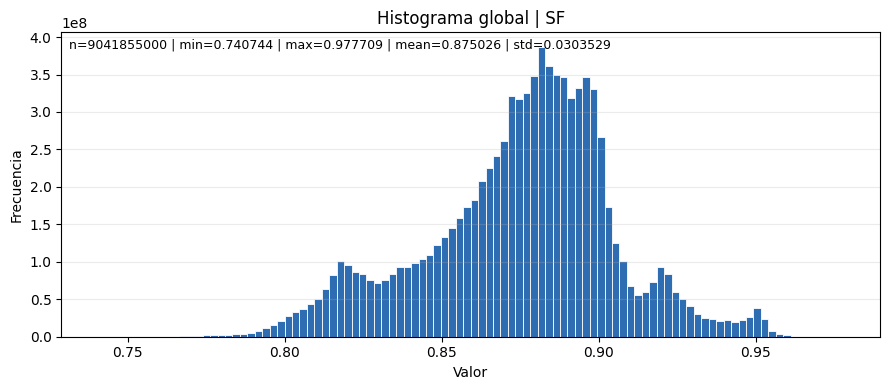

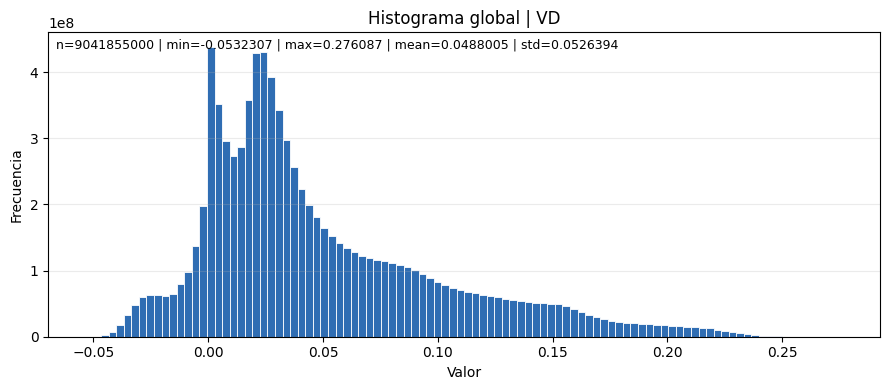

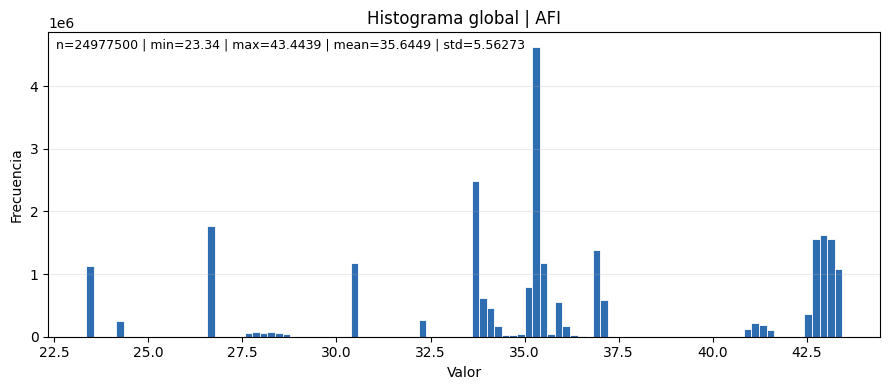

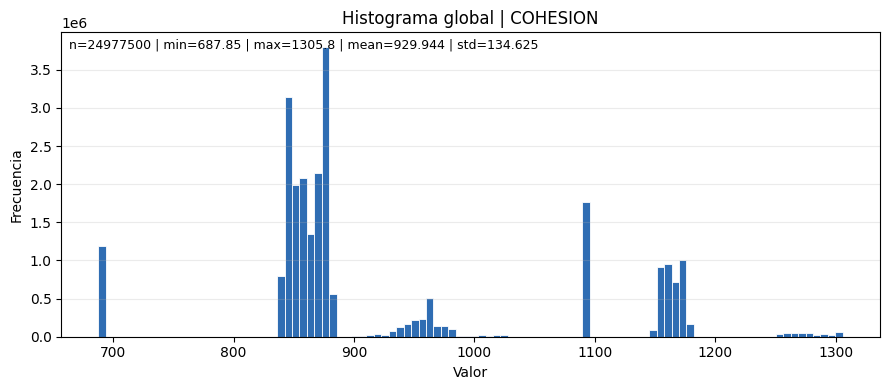

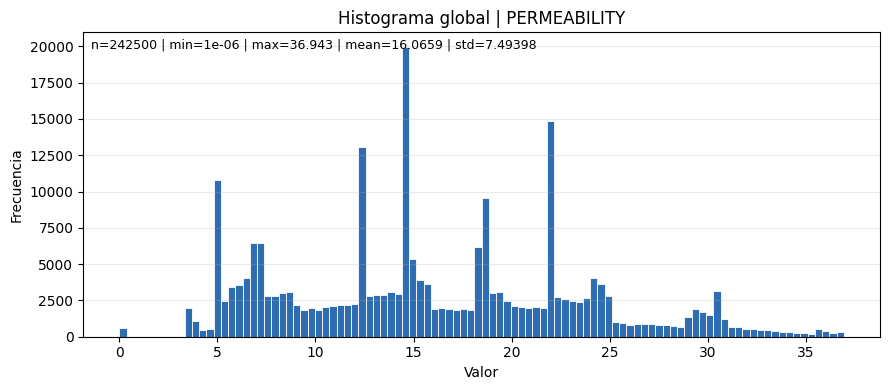

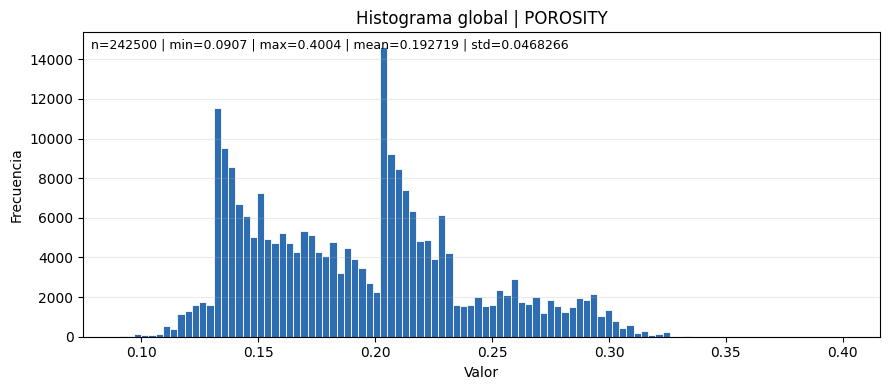

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 2 — Cuando lleguen simulaciones nuevas: solo leer las que faltan
# ─────────────────────────────────────────────────────────────────────────────
# actualizar_histogramas_nuevos()                   # todos los datasets
# actualizar_histogramas_nuevos(datasets=['sf_vd']) # solo sf_vd

# ─────────────────────────────────────────────────────────────────────────────
# PASO 3 — Graficar desde JSON (rápido, sin leer cubos)
# ─────────────────────────────────────────────────────────────────────────────
graficar_histograma_json('sf_vd', variable='SF')
graficar_histograma_json('sf_vd', variable='VD')
graficar_histograma_json('afi')
graficar_histograma_json('cohesion')
graficar_histograma_json('permeability')
graficar_histograma_json('porosity')

# ─────────────────────────────────────────────────────────────────────────────
# PASO 4 — Todas las variables de un dataset en una figura
# ─────────────────────────────────────────────────────────────────────────────
# graficar_todas_variables_dataset('sf_vd')
# graficar_todas_variables_dataset('sf_vd', log_y=True)

dataset: permeability
source: layer_cubes::L:\cmg22tensor\data\processed\001_LatinHyperCube\permeability_layer_cubes
shape (V,T,Z,J,I): (1, 1, 97, 50, 50)
variables: ['PERMEABILITY']
time_ids sample: [0]
normalization: {'applied': False, 'method': 'none', 'per_variable': {'PERMEABILITY': None}}
stats global: {'shape': (1, 1, 97, 50, 50), 'nan_count': 0, 'min': 9.999999974752427e-07, 'max': 36.94300079345703, 'mean': 16.06587028503418}


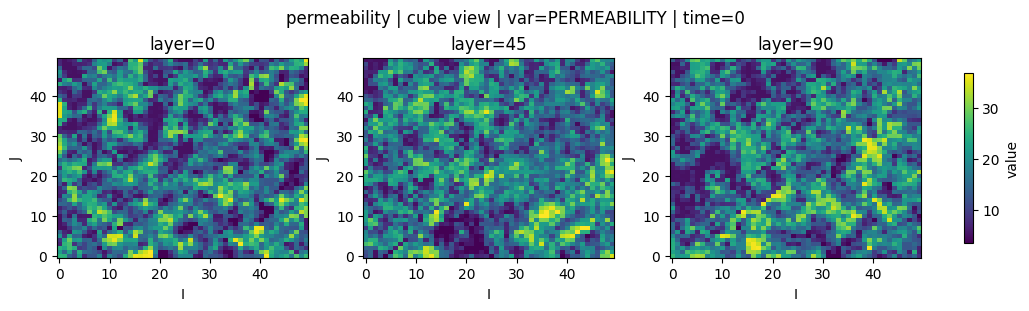

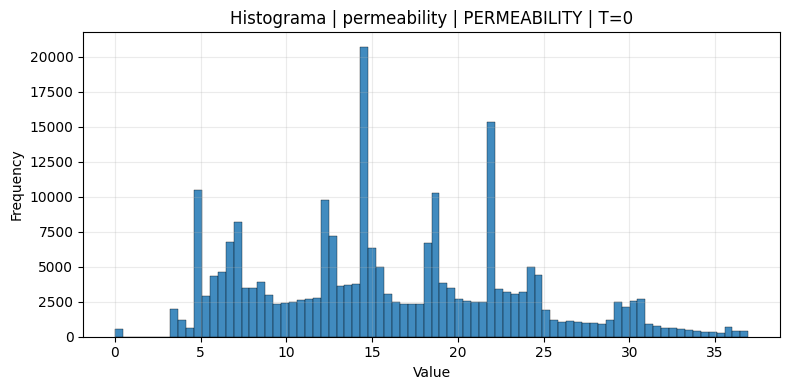

dataset: porosity
source: layer_cubes::L:\cmg22tensor\data\processed\001_LatinHyperCube\porosity_layer_cubes
shape (V,T,Z,J,I): (1, 1, 97, 50, 50)
variables: ['POROSITY']
time_ids sample: [0]
normalization: {'applied': False, 'method': 'none', 'per_variable': {'POROSITY': None}}
stats global: {'shape': (1, 1, 97, 50, 50), 'nan_count': 0, 'min': 0.09070000052452087, 'max': 0.4004000127315521, 'mean': 0.19271910190582275}


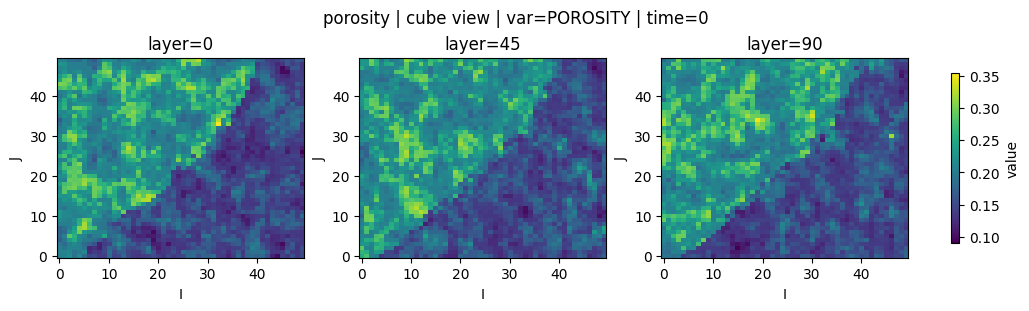

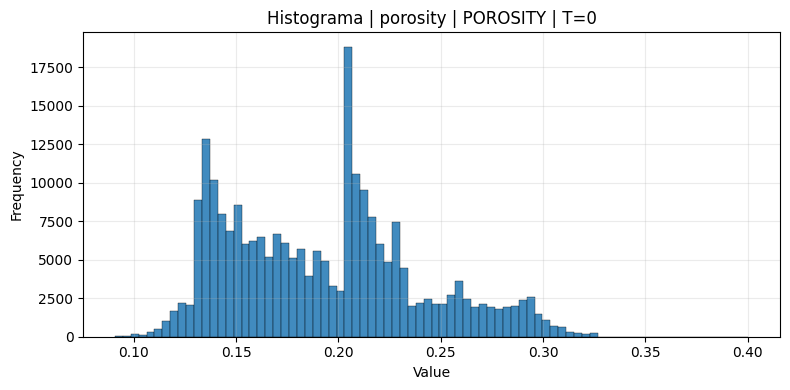

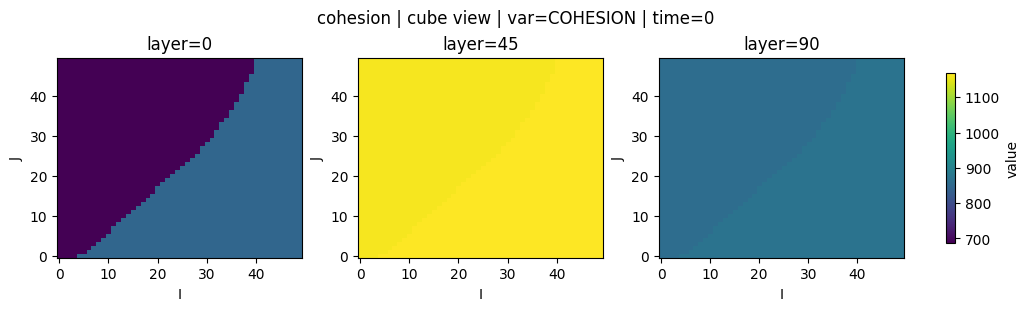

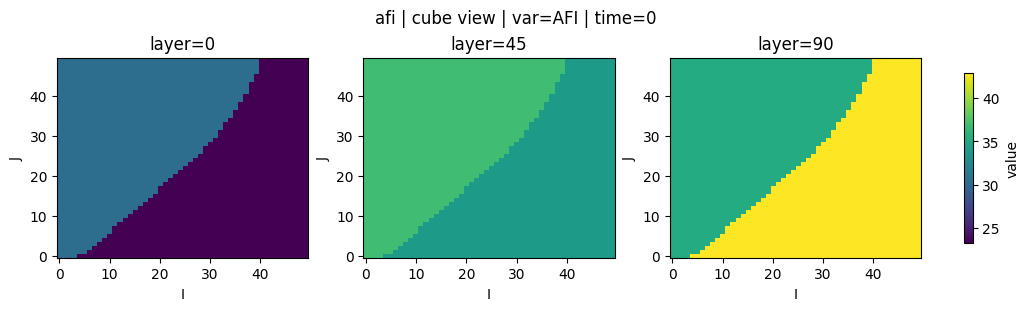

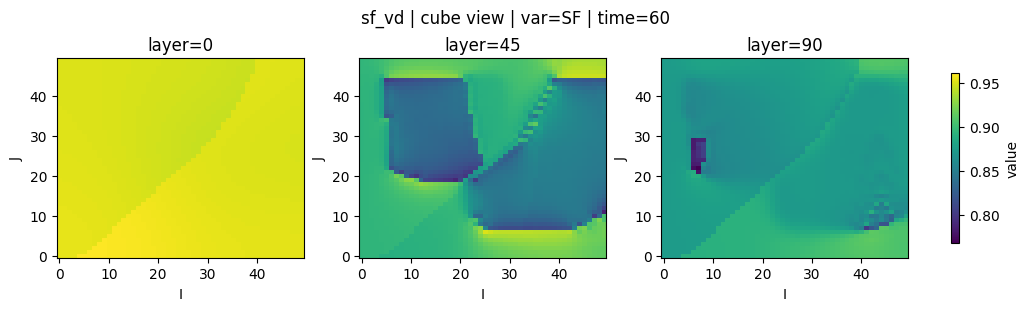

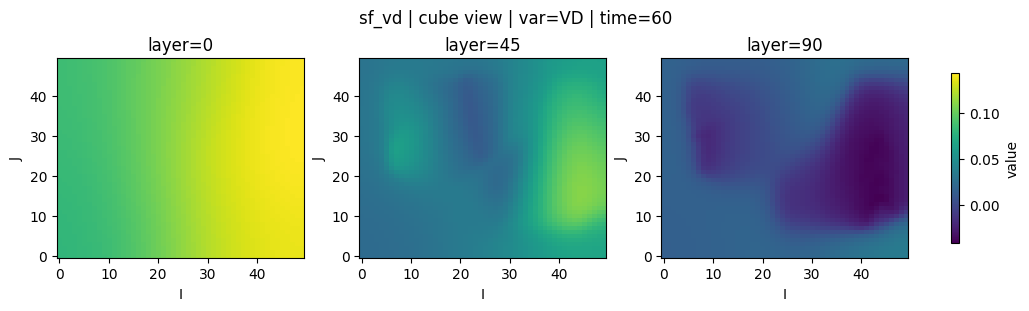

In [ ]:
# Uso minimo: solo llama la funcion con lo que quieres graficar
# ayuda_graficas()

# 1) Ver resumen del dataset
# resumen_dataset('permeability')

# 2) Graficar una capa puntual (layer, variable, tiempo)
# graficar_capa('sf_vd', capa=60, variable=0, tiempo=0)

# 3) Graficar el cubo completo para una variable+tiempo (mosaico de capas)
# graficar_cubo('permeability', variable=0 , tiempo=0)

# 4) Graficar solo algunas capas del cubo
# resumen_dataset('permeability')
# graficar_cubo('permeability', variable=0, tiempo=0, capas=[0, 45, 90])
graficar_histograma('permeability', variable=0, tiempo=0, capa=None, bins=80)


# resumen_dataset('porosity')
# graficar_cubo('porosity', variable=0, tiempo=0, capas=[0, 45, 90])
graficar_histograma('porosity', variable=0, tiempo=0, capa=None, bins=80)

# graficar_cubo('cohesion', variable=0, tiempo=0, capas=[0, 45, 90])
# graficar_cubo('afi', variable=0, tiempo=0, capas=[0, 45, 90])
# graficar_cubo('sf_vd', variable=0, tiempo=60, capas=[0, 45, 90])
# graficar_cubo('sf_vd', variable=1, tiempo=60, capas=[0, 45, 90])

# 5) Histograma del cubo completo o filtrando por tiempo/capa
# graficar_histograma('sf_vd', variable=0, tiempo=None, capa=None, bins=100)


# 6) Ver una misma capa a traves del tiempo
# graficar_capa_tiempo('sf_vd', capa=45, variable=0, tiempos=[0, 30, 60, 90, 120, 150, 180])
# graficar_capa_tiempo('sf_vd', capa=45, variable=1, tiempos=[0, 30, 60, 90, 120, 150, 180])
# graficar_capa_tiempo('pressure', capa=45, variable=0, tiempos=[0, 30, 60, 90, 120, 150, 180])
# graficar_capa_tiempo('gas_saturation', capa=45, variable=0, tiempos=[0, 30, 60, 90, 120, 150, 180])

# 7) Comparar una misma capa entre dos tiempos
# graficar_capa_diff_tiempo('sf_vd', variable=1, capa=45, t1=60, t2=120)



TENE-1: len=362, min=0.000, max=708852.625, mean=90637.224
TENE-2: len=362, min=0.000, max=1498842.750, mean=194417.090


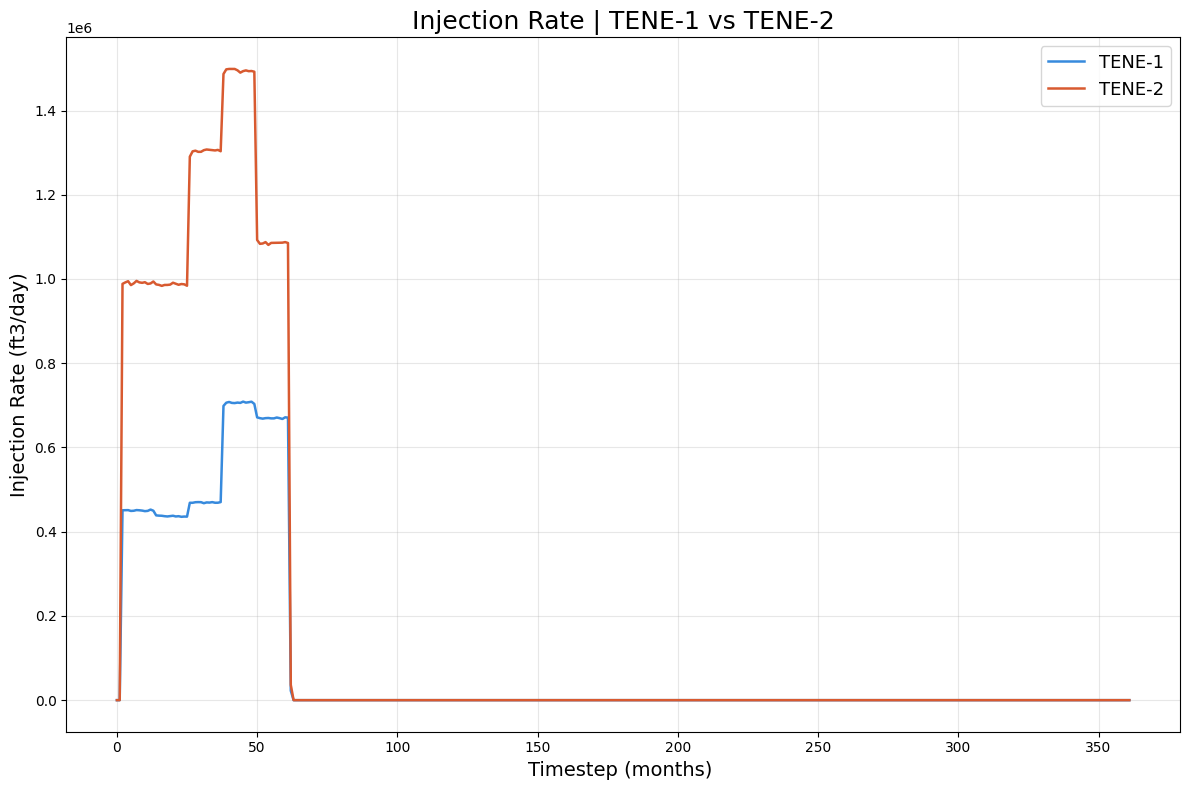

In [16]:
import re

injection_report = load_report('injection')
injection_dir = resolve_path_from_report(injection_report['output_dir'])

def load_injection_series(name: str) -> dict:
    slug = re.sub(r'[^a-zA-Z0-9]+', '_', name.strip().lower()).strip('_')
    pt_path = injection_dir / f'injection_{slug}.pt'
    npz_path = injection_dir / f'injection_{slug}.npz'

    if pt_path.exists():
        if torch is None:
            raise RuntimeError('No hay torch en el entorno para leer .pt')
        payload = torch.load(pt_path, map_location='cpu')
        series = payload['tensor']
        if hasattr(series, 'detach'):
            series = series.detach().cpu().numpy()
        return {
            'series': np.asarray(series, dtype=float),
            'time_ids': list(payload.get('time_ids', [])),
            'time_unit': str(payload.get('time_unit', 'months')),
            'norm': payload.get('normalization', None),
        }
    elif npz_path.exists():
        with np.load(npz_path, allow_pickle=True) as payload:
            return {
                'series': np.asarray(payload['tensor'], dtype=float),
                'time_ids': payload['time_ids'].tolist(),
                'time_unit': str(payload['time_unit'].tolist()[0]) if 'time_unit' in payload else 'months',
                'norm': None,
            }
    else:
        raise FileNotFoundError(f'No existe archivo para {name} en {injection_dir}')

INJECTION_NAMES = ['TENE-1', 'TENE-2']
colors = ['#378ADD', '#D85A30']

fig, ax = plt.subplots(figsize=(12, 8))

for name, color in zip(INJECTION_NAMES, colors):
    data = load_injection_series(name)
    series = data['series']
    time_ids = data['time_ids']
    x = np.asarray(time_ids) if time_ids else np.arange(len(series))
    ax.plot(x, series, linewidth=1.8, label=name, color=color)
    print(f'{name}: len={len(series)}, min={float(np.nanmin(series)):.3f}, max={float(np.nanmax(series)):.3f}, mean={float(np.nanmean(series)):.3f}')

ax.set_title('Injection Rate | TENE-1 vs TENE-2', fontsize=18)
ax.set_xlabel('Timestep (months) ', fontsize=14)
ax.set_ylabel('Injection Rate (ft3/day)', fontsize=14)
ax.legend(fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
